# **GCC Tertiary School Enrollment Analysis (2000–2024)**

By: Zahraa Al-Touq

**Project Overview:**

This project analyzes tertiary school enrollment trends across Gulf Cooperation Council (GCC) countries between 2000 and 2024 using World Bank data.

**The analysis focuses on understanding patterns in higher education enrollment across:**

* Total tertiary enrollment (% gross)
* Female tertiary enrollment (% gross)
* Male tertiary enrollment (% gross)

**Countries included:**

* Bahrain
* Kuwait
* Oman
* Qatar
* Saudi Arabia
* United Arab Emirates

**Project Objectives:**

* Explore tertiary education trends across GCC countries
* Compare enrollment patterns between countries
* Analyze gender differences in higher education participation
* Identify long-term trends and patterns
* Build visual insights and storytelling dashboards

**Workflow:**

1. Data Understanding
2. Data Cleaning
3. Data Transformation
4. Exploratory Data Analysis (EDA)
5. Data Visualization
6. Satistical and Correlation Analysis
7. Multiple Line Regression
8. Insights and Findings
9. Power BI Dashboard Development

**Data Source:**

World Bank Open Data

# 1- Data Understanding

## 1.1- Import Libraries and Data 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns

# Load dataset
df = pd.read_excel("/kaggle/input/datasets/zahraatouq/education-enrollment-across-gcc/Education Enrollment Across GCC.xlsx")

# Status update
print("DONE")

DONE


In [2]:
# Display basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    18 non-null     object 
 1   Country Code    18 non-null     object 
 2   Indicator Name  18 non-null     object 
 3   Indicator Code  18 non-null     object 
 4   2000            3 non-null      float64
 5   2001            9 non-null      float64
 6   2002            9 non-null      float64
 7   2003            15 non-null     float64
 8   2004            12 non-null     float64
 9   2005            12 non-null     float64
 10  2006            12 non-null     float64
 11  2007            9 non-null      float64
 12  2008            7 non-null      float64
 13  2009            9 non-null      float64
 14  2010            9 non-null      float64
 15  2011            12 non-null     float64
 16  2012            9 non-null      float64
 17  2013            12 non-null     float

In [3]:
# Preview dataset
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Bahrain,BHR,"School enrollment, tertiary (% gross)",SE.TER.ENRR,NaN,NaN,NaN,25.120140,NaN,19.013639,...,46.763177,48.728098,50.262834,52.904578,54.407792,47.501553,50.307376,57.056224,58.367724,NaN
1,Bahrain,BHR,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,NaN,NaN,NaN,40.010841,NaN,34.647179,...,63.049723,65.192674,67.328676,71.724351,75.291455,67.076978,73.607365,84.325444,79.939272,NaN
2,Bahrain,BHR,"School enrollment, tertiary, male (% gross)",SE.TER.ENRR.MA,NaN,NaN,NaN,15.654480,NaN,9.742300,...,33.951023,35.609756,36.924640,38.396331,38.914054,33.577082,34.772364,39.099178,42.670405,NaN
3,Kuwait,KWT,"School enrollment, tertiary (% gross)",SE.TER.ENRR,NaN,18.32074,19.27953,19.589060,19.97464,NaN,...,59.221339,54.915962,52.106689,50.440060,53.731879,51.896718,NaN,NaN,NaN,NaN
4,Kuwait,KWT,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,NaN,27.36805,28.42988,28.852060,28.71595,NaN,...,83.888889,77.423191,74.509999,72.064350,73.675329,65.940869,NaN,NaN,NaN,NaN


**Data Structure Observation**

The dataset is in a wide format where each year (2000–2025) is represented as a separate column.
Each row represents a combination of:
- Country
- Indicator (Total / Female / Male enrollment)

This structure is not optimal for time-series analysis or visualization tools like Power BI. Therefore, the dataset will be transformed into a long format in the next step.

# 2- Data Cleaning

In this step, we will inspect and handle data quality issues such as missing values, inconsistent formatting, and structural adjustments after reshaping the dataset into a long format.

##  2.1- Missing Value Assesment

In [4]:
# Check missing values
df.isnull().sum()

# Status update
print("DONE")

DONE


**Missing Values Observation**

Missing values are mainly concentrated across yearly columns and are not randomly distributed. The missing pattern appears to be related to data availability from the original World Bank source rather than data corruption or collection errors. Further handling decisions will be made after reshaping the dataset into a long format.

## 2.2- Reshape Dataset

In [5]:
# Convert wide format to long format
df_long = df.melt(
    id_vars=["Country Name", "Country Code",
             "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Enrollment"
)

# Status update
print("DONE")

DONE


In [6]:
# Preview reshaped dataset
df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Enrollment
0,Bahrain,BHR,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000,NaN
1,Bahrain,BHR,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,2000,NaN
2,Bahrain,BHR,"School enrollment, tertiary, male (% gross)",SE.TER.ENRR.MA,2000,NaN
3,Kuwait,KWT,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000,NaN
4,Kuwait,KWT,"School enrollment, tertiary, female (% gross)",SE.TER.ENRR.FE,2000,NaN


## 2.3- Data Type Adjustment

In [7]:
# Convert year to numeric
df_long["Year"] = pd.to_numeric(df_long["Year"])

# Status update
print("DONE")

DONE


## 2.4- Remove Empty Year Column

In [8]:
# Remove empty year column records
df_long = df_long[df_long["Year"] != 2025]

# Verify cleaned dataset shape
df_long.shape

(450, 6)

## Data Cleaning Summary

The dataset was successfully reshaped from a wide structure into a long format.

Key cleaning actions performed:

- Converted yearly columns into a single Year column
- Created an Enrollment value column
- Adjusted data types
- Removed the empty 2025 records

The dataset is now structured for analysis and visualization.

# 3- Data Transformation

## 3.1- Simplify Indicator Names

In [9]:
# Simplify indicator names
df_long["Indicator Name"] = df_long["Indicator Name"].replace({
    "School enrollment, tertiary (% gross)": "Total",
    "School enrollment, tertiary, female (% gross)": "Female",
    "School enrollment, tertiary, male (% gross)": "Male"
})

# Status update
print("DONE")

DONE


## 3.2- Rename Column  

In [10]:
# Rename columns
df_long = df_long.rename(columns={
    "Country Name": "Country",
    "Country Code": "Country_Code",
    "Indicator Name": "Category",
    "Indicator Code": "Indicator_Code"
})

# Display updated columns
df_long.columns


Index(['Country', 'Country_Code', 'Category', 'Indicator_Code', 'Year',
       'Enrollment'],
      dtype='object')

# 4- Exploratory Data Analysis (EDA)

## 4.1- Basic Statistics Overview

In [11]:
# Basic statistics
df_long.describe()


,Year,Enrollment
count,450.000000,307.000000
mean,2012.000000,39.619018
std,7.219128,21.439470
min,2000.000000,4.406313
25%,2006.000000,20.427430
50%,2012.000000,35.914796
75%,2018.000000,56.519426
max,2024.000000,84.745171


## Key Statistical Insights

- Enrollment values vary widely across countries and years, ranging from very low (~4%) to high (~84%).
- The average enrollment rate is around 39.6%, indicating moderate participation in tertiary education across GCC countries.
- The standard deviation suggests high variability, meaning countries and years differ significantly in enrollment trends.

## 4.2- Enrollment Trend Over Time (Overall)

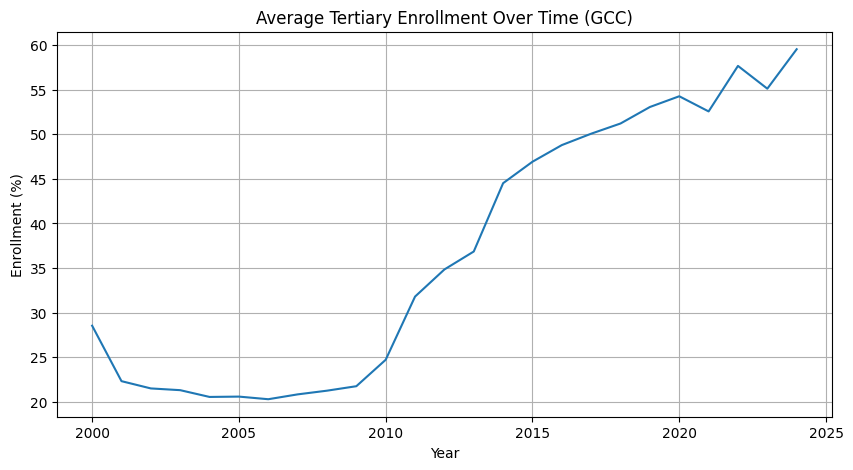

In [12]:
# Aggregate by year
yearly_trend = df_long.groupby("Year")["Enrollment"].mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(yearly_trend.index, yearly_trend.values)

plt.title("Average Tertiary Enrollment Over Time (GCC)")
plt.xlabel("Year")
plt.ylabel("Enrollment (%)")
plt.grid(True)

plt.show()

## 4.3- Gender Gap in Tertiary Education

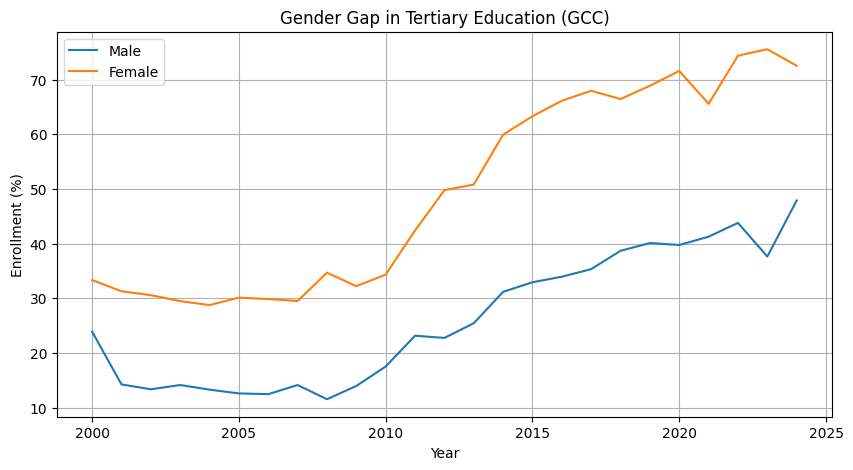

In [13]:
df_gender = df_long[df_long["Category"].isin(["Male", "Female"])]

# Average by year and category
gender_trend = df_gender.groupby(["Year", "Category"])["Enrollment"].mean().unstack()

# Plot
plt.figure(figsize=(10,5))

plt.plot(gender_trend.index, gender_trend["Male"], label="Male")
plt.plot(gender_trend.index, gender_trend["Female"], label="Female")

plt.title("Gender Gap in Tertiary Education (GCC)")
plt.xlabel("Year")
plt.ylabel("Enrollment (%)")
plt.grid(True)
plt.legend()

plt.show()


## Key Insight: Gender Gap Evolution

The data shows a clear structural shift in tertiary education participation across GCC countries.

- Female enrollment has grown significantly faster than male enrollment over time.
- A major acceleration occurred after 2010.
- The gender gap has narrowed in recent years, but remains present.

This indicates strong progress in female higher education participation across the region.

## Final EDA Summary

- Tertiary enrollment in GCC countries shows a general upward trend over time, with noticeable acceleration after 2015.
- The dataset reveals high variability across countries and years, indicating uneven educational development.
- Gender analysis shows a consistent increase in female participation, with a narrowing gap between male and female enrollment over time.
- Missing data patterns are mainly due to historical data availability rather than data quality issues.
- Overall, the GCC region shows strong progress in higher education expansion over the last two decades.

# 5- Satistical Analysis

## 5.1- Basic statistics by category 

In [14]:
# Basic statistics by category

stats = df_long.groupby("Category")["Enrollment"].agg(
    ['mean','median','std','min','max']
)

stats

,mean,median,std,min,max
Category,,,,,
Female,53.021804,56.798980,19.444969,12.185690,84.745171
Male,28.482729,28.848052,18.498863,4.406313,83.646600
Total,37.374525,36.044411,18.893414,9.642733,83.884130


In [15]:
import numpy as np

print("NumPy loaded successfully")

NumPy loaded successfully


## Statistical Insight

Female tertiary enrollment demonstrates consistently higher average participation compared to male enrollment across GCC countries. The similarity between mean and median values suggests relatively balanced distributions without extreme skewness. Standard deviations are comparable across categories, indicating similar variability 

## 5.2- Hypothesis Testing

Null Hypothesis (H0):
There is no significant difference between male and female tertiary enrollment rates.

Alternative Hypothesis (H1):
There is a significant difference between male and female tertiary enrollment rates.

In [16]:
female = df_long[df_long["Category"]=="Female"]["Enrollment"].dropna()
male = df_long[df_long["Category"]=="Male"]["Enrollment"].dropna()

t_stat, p_value = ttest_ind(female, male)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 9.23415385717567
P-value: 3.6374799214553037e-17


## Statistical Insight
Since the p-value is significantly lower than 0.05, the null hypothesis is rejected.
This indicates a statistically significant difference between male and female tertiary enrollment rates across GCC countries.

# 6- Correlation Analysis

The correlation coefficient between Year and Enrollment is 0.65.

This indicates a moderate to strong positive relationship, suggesting that tertiary enrollment generally increased over time.

However, the relationship is not perfect, implying that additional factors beyond time likely influence enrollment patterns.

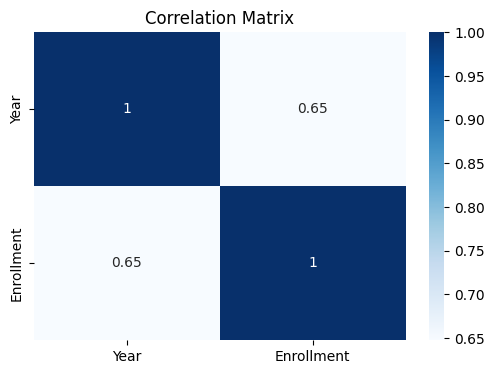

In [17]:
corr_df = df_long[['Year','Enrollment']]

correlation = corr_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis Insight

The correlation coefficient between Year and Enrollment is 0.65.

This indicates a moderate to strong positive relationship, suggesting that tertiary enrollment generally increased over time.
However, the relationship is not perfect, implying that additional factors beyond time likely influence enrollment patterns.

# 7- Multiple Linear Regression

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Select features and target
model_df = df_long[['Year','Country','Category','Enrollment']].dropna()

# One-hot encoding for categorical variables
model_df = pd.get_dummies(
    model_df,
    columns=['Country','Category'],
    drop_first=True
)

# Features and target
X = model_df.drop('Enrollment', axis=1)
y = model_df['Enrollment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R² Score:", round(r2_score(y_test,y_pred),3))
print("MAE:", round(mean_absolute_error(y_test,y_pred),3))

R² Score: 0.751
MAE: 8.432


## Regression Results

The multiple linear regression model achieved:

- R² Score = 0.751
- Mean Absolute Error (MAE) = 8.432

The model explains approximately 75% of the variability in tertiary enrollment rates. This suggests that year, country, and category variables collectively provide substantial predictive power, although additional socioeconomic variables could further improve model performance.

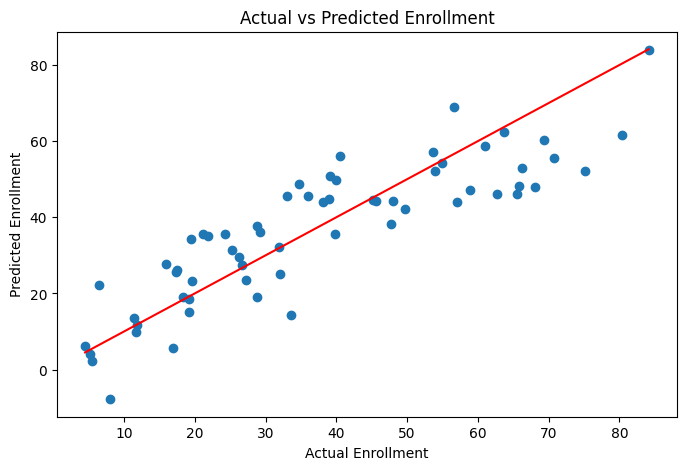

In [19]:

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.title("Actual vs Predicted Enrollment")

plt.show()

## Actual vs Predicted Interpretation

The scatter plot shows that most predicted values are reasonably close to the reference line. Points located near the red line indicate accurate predictions, while points farther away represent prediction errors.

Although not all observations perfectly align with the line, the overall pattern suggests that the model captures the general trend in tertiary enrollment effectively and some deviations are expected because additional factors influencing enrollment were not included in the model.

# Project Conclusion


This project explored tertiary education enrollment trends across GCC countries between 2000 and 2024. The analysis revealed an overall increase in enrollment rates over time, with noticeable differences across gender categories and countries.Statistical testing confirmed significant differences between male and female enrollment rates. Additionally, the regression model demonstrated reasonable predictive performance, explaining approximately 75% of the variation in enrollment patterns.Future improvements may include integrating additional socioeconomic variables such as GDP, education expenditure, and population metrics to enhance predictive capability.


In [20]:
df_long.to_csv("gcc_tertiary_cleaned.csv", index=False)